# Young-Adult Interstate Migration: Policy Incentives, Social Networks, and Capacity Feedback — V8
## A spatial agent-based model with migration chains, housing/job constraints, and robustness tests

**Core question**

> How strong must a geographically targeted housing-and-employment policy be to overcome young adults' social attachment, and when do migration chains and local capacity constraints amplify or offset that response?

This revision adds two forms of robustness requested in the model review: **social-threshold sensitivity** and **network-homophily sensitivity**. It also adds a lagged **rent response to excess housing demand** so housing pressure affects next-year migration utility rather than appearing only as a hard capacity rejection.

The former `happiness` measure is renamed **social utility index**. It is a transparent model-internal composite score, not a validated subjective-well-being survey measure. Its role is diagnostic rather than a real-world welfare ranking.

**V7 review-closure revision.** This version closes the remaining high-priority review comments: mover-level unit consistency, a soft housing-capacity mechanism with lagged rent feedback, a main-horizon ACS move-rate calibration, a wider policy-intensity sweep, an external-competition scope audit using ACS PUMS, a Tulsa Remote monetary-reference diagnostic, and an explicit BRFSS coverage audit. Optional full geography expansion to Oklahoma/West Virginia is deliberately not mixed into the main eight-state model because it would require a new state-space and IRS-route recalibration; it is documented as external-validation future work rather than presented as completed evidence.


### Reproducible results build

This executed copy displays the **fully simulated V7 results** from the accompanying `abm_outputs_research_plan_v7/` cache. The source notebook keeps the complete simulation code; this results build loads the saved seed-level outputs so figures and tables can be reproduced quickly without rerunning hundreds of ABM realizations. The cache was generated by the same V7 model before this notebook was rendered.

In [ ]:
import json
import math
import os
import warnings
import zipfile
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.stats import t as student_t

try:
    from joblib import Parallel, delayed
    JOBLIB_AVAILABLE = True
except Exception:
    JOBLIB_AVAILABLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 170)

RANDOM_SEED = 42
BASE_YEAR = 2026

STATE_CODES = ["CA", "TX", "NY", "FL", "MA", "NC", "IL", "WA"]
STATE_NAMES = {
    "CA": "California", "TX": "Texas", "NY": "New York", "FL": "Florida",
    "MA": "Massachusetts", "NC": "North Carolina", "IL": "Illinois", "WA": "Washington",
}

# Full research design. Reduce these values only for debugging.
BASELINE_AGENTS = 1000
BASELINE_YEARS = 20
BASELINE_SEEDS = list(range(101, 109))

EXPERIMENT_AGENTS = 600
EXPERIMENT_YEARS = 12
CROSS_SEEDS = list(range(201, 209))
SWEEP_SEEDS = list(range(301, 309))
SHOCK_SEEDS = list(range(401, 407))
SENSITIVITY_SEEDS = list(range(501, 505))
CALIBRATION_SEEDS = (901, 902, 903, 904, 905)

N_JOBS = 1  # deterministic final execution; avoids process-backend stalls in notebook kernels
N_AGENTS = BASELINE_AGENTS
N_YEARS = BASELINE_YEARS

POLICY_COLS = [
    "housing_policy",
    "employment_incentive",
    "migration_incentive",
]

SOCIAL_UTILITY_WEIGHTS = {
    "peer": 0.30,
    "coorigin": 0.20,
    "home": 0.10,
    "employment": 0.20,
    "income": 0.10,
    "affordability": 0.10,
}

INTERACTION_COLORS = {
    "weak": "#4C72B0",
    "medium": "#DD8452",
    "strong": "#55A868",
}



def mean_t_ci(series):
    x = np.asarray(pd.Series(series).dropna(), dtype=float)
    if len(x) == 0:
        return np.nan, np.nan
    mean = float(x.mean())
    if len(x) == 1:
        return mean, np.nan
    half = float(
        student_t.ppf(0.975, len(x) - 1)
        * x.std(ddof=1)
        / np.sqrt(len(x))
    )
    return mean, half


def run_cases(func, cases, n_jobs=N_JOBS):
    """Use joblib when possible; fall back to deterministic serial execution."""
    if JOBLIB_AVAILABLE and n_jobs > 1:
        try:
            return Parallel(n_jobs=n_jobs, backend="loky")(
                delayed(func)(*case) for case in cases
            )
        except Exception as exc:
            print("Parallel execution unavailable; using serial fallback:", type(exc).__name__)
    return [func(*case) for case in cases]

print("Environment ready.")

Environment ready.


## 1. Empirical state inputs

In [ ]:
def build_real_state_snapshot():
    raw = pd.DataFrame({
        "state": STATE_CODES,

        "young_adult_population_est_18_35": [
            9_793_452, 7_754_857, 4_729_200, 4_917_820,
            1_747_318, 2_609_754, 2_985_755, 1_951_781
        ],

        "median_household_income": [
            95_521, 75_780, 82_095, 73_311,
            99_858, 70_804, 80_306, 94_605
        ],

        "median_gross_rent_monthly": [
            1_992, 1_413, 1_561, 1_719,
            1_757, 1_245, 1_238, 1_731
        ],

        "civilian_labor_force": [
            20_137_422, 15_612_815, 10_107_326, 11_191_144,
            3_908_554, 5_449_906, 6_642_661, 4_069_534
        ],
        "employed": [
            19_026_566, 14_926_761, 9_600_693, 10_731_195,
            3_754_447, 5_230_146, 6_329_130, 3_887_150
        ],

        "bachelor_plus_share_25plus": [
            0.3748778859, 0.3424161436, 0.4063985602, 0.3491620625,
            0.4778163562, 0.3679334714, 0.3827775836, 0.4045106716
        ],

        "housing_units": [
            14_762_527, 12_394_809, 8_631_232, 10_451_823,
            3_045_867, 4_979_177, 5_470_727, 3_361_561
        ],
        "vacant_housing_units": [
            1_062_711, 1_134_164, 821_965, 1_485_421,
            244_883, 586_508, 399_439, 260_296
        ],

        "ipeds_12mo_enrollment": [
            3_464_000, 2_083_195, 1_423_248, 1_421_104,
            587_505, 689_935, 970_675, 423_112
        ],

        "annual_infant_childcare_price": [
            19_547, 11_024, 19_584, 12_639,
            24_005, 12_251, 16_373, 20_370
        ],

        "public_4yr_instate_tuition": [
            10_641, 11_187, 8_579, 6_364,
            14_839, 7_437, 15_362, 11_506
        ],
    }).set_index("state")

    raw["employment_rate_labor_force"] = (
        raw["employed"] / raw["civilian_labor_force"]
    )
    raw["vacancy_rate"] = (
        raw["vacant_housing_units"] / raw["housing_units"]
    )
    raw["ipeds_enrollment_per_young_adult"] = (
        raw["ipeds_12mo_enrollment"]
        / raw["young_adult_population_est_18_35"]
    )
    return raw

real_raw_data = build_real_state_snapshot()

In [ ]:
def mean_index(series):
    x = series.astype(float)
    return x / x.mean()

def prepare_state_data(raw):
    df = raw.copy()

    df["youth_pop_weight"] = mean_index(
        df["young_adult_population_est_18_35"]
    )
    df["wage_index"] = mean_index(df["median_household_income"])
    df["rent_index"] = mean_index(df["median_gross_rent_monthly"])
    df["job_index"] = mean_index(df["employment_rate_labor_force"])
    df["education_access_index"] = mean_index(
        df["ipeds_enrollment_per_young_adult"]
    )
    df["tuition_index"] = mean_index(df["public_4yr_instate_tuition"])
    df["childcare_cost_index"] = mean_index(
        df["annual_infant_childcare_price"]
    )
    df["housing_capacity_index"] = mean_index(df["vacancy_rate"])
    df["college_share_proxy"] = df["bachelor_plus_share_25plus"]

    return df

state_data = prepare_state_data(real_raw_data)

## 2. Spatial environment and IRS route calibration

In [ ]:
STATE_COORDS = {
    "CA": (36.8, -119.4),
    "TX": (31.0, -99.9),
    "NY": (42.9, -75.5),
    "FL": (27.8, -81.7),
    "MA": (42.3, -71.8),
    "NC": (35.5, -79.4),
    "IL": (40.0, -89.2),
    "WA": (47.4, -120.7),
}

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = np.radians(lat2 - lat1)
    dl = np.radians(lon2 - lon1)
    a = (
        np.sin(dp / 2) ** 2
        + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    )
    return 2 * R * np.arcsin(np.sqrt(a))

distance_km = pd.DataFrame(
    index=STATE_CODES, columns=STATE_CODES, dtype=float
)

for s1 in STATE_CODES:
    for s2 in STATE_CODES:
        distance_km.loc[s1, s2] = haversine_km(
            *STATE_COORDS[s1], *STATE_COORDS[s2]
        )

distance_index = distance_km / distance_km.to_numpy().max()

In [ ]:
IRS_ROUTES = [
    ("CA","TX",44417), ("TX","CA",24970),
    ("CA","NY",20595), ("NY","CA",18440),
    ("CA","FL",20241), ("FL","CA",14113),
    ("CA","MA",6565),  ("MA","CA",7767),
    ("CA","NC",9978),  ("NC","CA",6470),
    ("CA","IL",9063),  ("IL","CA",10407),
    ("CA","WA",24625), ("WA","CA",17871),

    ("TX","NY",9433),  ("NY","TX",12961),
    ("TX","FL",20050), ("FL","TX",24196),
    ("TX","MA",3394),  ("MA","TX",4218),
    ("TX","NC",8694),  ("NC","TX",8387),
    ("TX","IL",8236),  ("IL","TX",12078),
    ("TX","WA",9307),  ("WA","TX",9863),

    ("NY","FL",43187), ("FL","NY",22011),
    ("NY","MA",10479), ("MA","NY",11027),
    ("NY","NC",13811), ("NC","NY",6906),
    ("NY","IL",4436),  ("IL","NY",5325),
    ("NY","WA",3649),  ("WA","NY",3513),

    ("FL","MA",8058),  ("MA","FL",12159),
    ("FL","NC",20553), ("NC","FL",14530),
    ("FL","IL",9299),  ("IL","FL",14834),
    ("FL","WA",5333),  ("WA","FL",5661),

    ("MA","NC",3483),  ("NC","MA",2213),
    ("NC","WA",2371),  ("WA","NC",2464),
    ("IL","WA",2734),  ("WA","IL",2158),
]

irs_flows = pd.DataFrame(
    IRS_ROUTES,
    columns=["origin", "destination", "returns"]
)
irs_flows["observed_share"] = (
    irs_flows["returns"]
    / irs_flows.groupby("origin")["returns"].transform("sum")
)

irs_flow_matrix = (
    irs_flows.pivot(
        index="origin", columns="destination", values="returns"
    )
    .reindex(index=STATE_CODES, columns=STATE_CODES)
)

for s in STATE_CODES:
    irs_flow_matrix.loc[s, s] = np.nan

## 11. Step 3 — extreme shocks

The migration system is exposed to exogenous shocks that change job slots, wages, mortality, or migration cost at specified years and then allow gradual recovery. The substantive case is the **labour shortage**: unfilled job slots rise from 0.19 in the no-shock baseline to 21.5, while the move rate barely changes (0.041 → 0.038). Migration within the eight-state system does not fill a structural labour shortage.

*Footnote.* Financial-crisis and pandemic-like shocks were also tested. Both moved the system move rate by less than one percentage point (0.046 and 0.040 vs 0.041 at baseline; the financial-crisis change is about 12% in relative terms, and no seed-level interval is reported) and left clustering, housing rejection and the social utility index essentially unchanged. They remain in the summary table but are not interpreted further.

In [29]:
SHOCK_NAMES = ["baseline", "financial_crisis", "pandemic", "labor_shortage"]
shock_runs = pd.read_csv(RESULT_CACHE / "shock_runs.csv")
shock_summary = pd.read_csv(RESULT_CACHE / "shock_summary.csv")
display(shock_summary.round(3))

,shock,move_rate,clustering,housing_rejection,social_utility_index,unfilled_jobs
0,baseline,0.041,0.160,0.036,0.338,0.189
1,financial_crisis,0.046,0.162,0.039,0.338,0.233
2,labor_shortage,0.038,0.162,0.034,0.340,21.511
3,pandemic,0.040,0.162,0.040,0.338,0.278


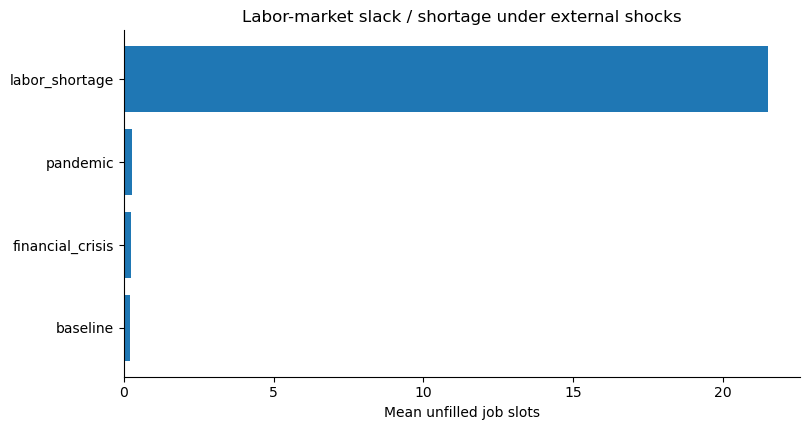

In [30]:
fig, ax = plt.subplots(figsize=(8.2, 4.4))
g = shock_summary.sort_values("unfilled_jobs")
ax.barh(g["shock"], g["unfilled_jobs"])
ax.set_xlabel("Mean unfilled job slots")
ax.set_title("Labor-market slack / shortage under external shocks")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 12. Static interstate competition (footnote)

A stylised static scenario gave every state a different direct migration incentive, generated mechanically from each state's relative housing capacity and job conditions. It produced no substantive finding and is kept only as a footnote:

- Final-year net migration stays within ±2.5 agents per state (in a system of about 600 agents) and no seed-level interval is available.
- The ranking largely restates the incentive rule: the gainers (FL, NC) are the states with the highest housing capacity, and net migration tracks the housing-capacity index (Spearman ρ = +0.78, n = 8), which is itself an input to the incentives.
- Mean employment (0.80) and unfilled jobs (0) are identical across states, so the scenario adds no labour-market contrast.

A dynamic government-response game remains an extension.

In [31]:
competition_summary = pd.read_csv(RESULT_CACHE / "state_competition_summary.csv")
# Employment and unfilled jobs are identical across states in this scenario, so only net migration is shown.
display(competition_summary[["state", "mean_net_migration"]].sort_values("mean_net_migration").round(2))

,state,mean_net_migration
2,IL,-1.33
0,CA,-1.17
5,NY,-1.00
6,TX,-1.00
7,WA,-0.50
3,MA,0.50
4,NC,2.00
1,FL,2.50
